In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Let's inspect the files
import os
print(os.listdir('.'))

# Load online_dataset.csv
df = pd.read_csv('online_dataset.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())
print(df.tail())
print(df.info())

['Fellow ', 'distributions.png', 'Daftar Ulang', '~$enosis aorta.docx', '.DS_Store', 'cx.analytics.ipynb', 'performance.analytics.ipynb', 'Customer_Data_Cleaned.csv', 'revenue_by_city.png', '.localized', '~$ripsi Tissa 20191028 bismillah sempro.docx', 'online_dataset.csv', 'Customer_Data.csv', 'IBM', 'Challenge - Lomba', 'Triple Degree Journey ', 'ml_model_evaluation.png', 'GitHub', 'Book - Library', 'Zoom', 'Portfolio', 'Professional ', '.ipynb_checkpoints', 'CV', 'Project ', '~$KAPAN SOAL CBT A6 REG 16.docx', 'VSCODE', 'javaApps', 'online_dataset.xlsx', 'revenue_vs_orders.png']
Shape: (401, 9)
Columns: ['Order ID', 'Tanggal', 'Kota', 'Kategori Produk', 'Channel Marketing', 'Qty', 'Revenue (Rp)', 'Cost (Rp)', 'Profit (Rp)']
   Order ID     Tanggal        Kota Kategori Produk Channel Marketing  Qty  \
0  ORD-0023  2025-08-01    Surabaya      Kecantikan           Organik    1   
1  ORD-0059  2025-08-01    Surabaya    Rumah Tangga        Google Ads    2   
2  ORD-0061  2025-08-01    Maka

In [18]:
# Clean data
clean_df = df.dropna(subset=['Order ID']).copy()

# Convert currency strings if needed
for col in ['Revenue (Rp)', 'Cost (Rp)', 'Profit (Rp)']:
    if clean_df[col].dtype == 'object':
        clean_df[col] = clean_df[col].astype(str).str.replace(',', '').str.replace('.', '').astype(float)

clean_df['Tanggal'] = pd.to_datetime(clean_df['Tanggal'])
clean_df['Profit_Margin'] = clean_df['Profit (Rp)'] / clean_df['Revenue (Rp)']
clean_df['Price_Per_Unit'] = clean_df['Revenue (Rp)'] / clean_df['Qty']
clean_df['Day_of_Week'] = clean_df['Tanggal'].dt.day_name()

print(clean_df.info())
print(clean_df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order ID           400 non-null    object        
 1   Tanggal            400 non-null    datetime64[ns]
 2   Kota               400 non-null    object        
 3   Kategori Produk    400 non-null    object        
 4   Channel Marketing  400 non-null    object        
 5   Qty                400 non-null    int64         
 6   Revenue (Rp)       400 non-null    float64       
 7   Cost (Rp)          400 non-null    float64       
 8   Profit (Rp)        400 non-null    float64       
 9   Profit_Margin      400 non-null    float64       
 10  Price_Per_Unit     400 non-null    float64       
 11  Day_of_Week        400 non-null    object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(5)
memory usage: 40.6+ KB
None
                   Tanggal         Qty   Re

/var/folders/n4/5f0j234x5m79703ndtqxkcr00000gn/T/ipykernel_1671/3054264125.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=chan_perf.values, y=chan_perf.index, ax=axes[1, 0], palette='Blues_r')
/var/folders/n4/5f0j234x5m79703ndtqxkcr00000gn/T/ipykernel_1671/3054264125.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Profit_Margin', y='Channel Marketing', data=clean_df, ax=axes[1, 1], palette='Set2')


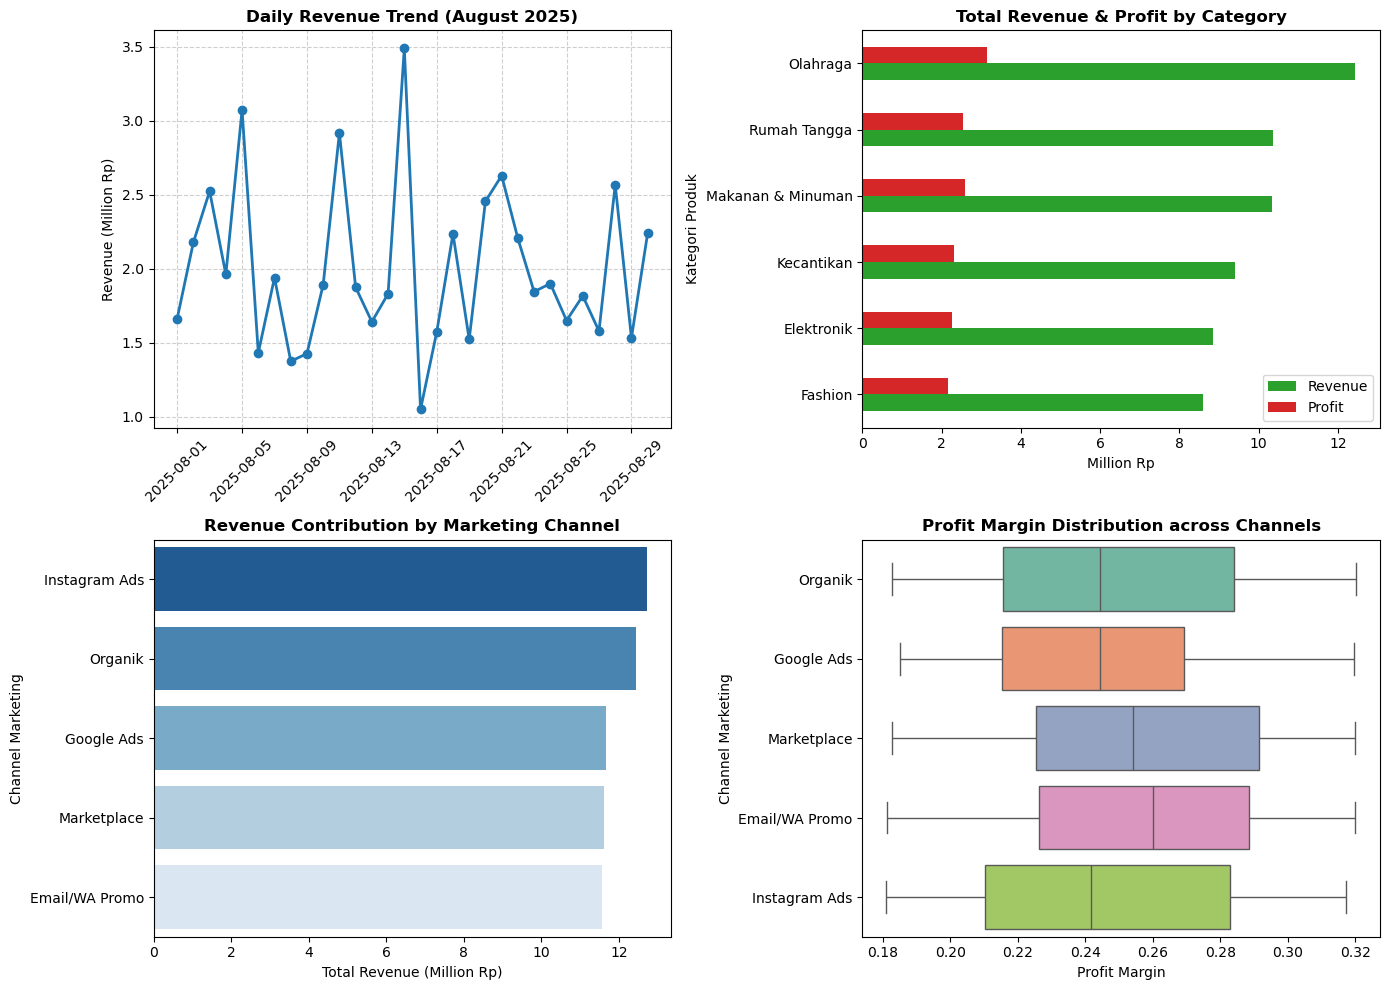

In [15]:
# Generate Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Daily Revenue Trend
daily_sales = clean_df.groupby('Tanggal')['Revenue (Rp)'].sum() / 1e6
axes[0, 0].plot(daily_sales.index, daily_sales.values, marker='o', color='#1f77b4', linewidth=2)
axes[0, 0].set_title('Daily Revenue Trend (August 2025)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Revenue (Million Rp)')
axes[0, 0].grid(True, linestyle='--', alpha=0.6)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Revenue & Profit by Product Category
cat_perf = clean_df.groupby('Kategori Produk')[['Revenue (Rp)', 'Profit (Rp)']].sum() / 1e6
cat_perf.sort_values(by='Revenue (Rp)', ascending=True).plot(kind='barh', ax=axes[0, 1], color=['#2ca02c', '#d62728'])
axes[0, 1].set_title('Total Revenue & Profit by Category', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Million Rp')
axes[0, 1].legend(['Revenue', 'Profit'])

# 3. Revenue by Marketing Channel
chan_perf = clean_df.groupby('Channel Marketing')['Revenue (Rp)'].sum().sort_values(ascending=False) / 1e6
sns.barplot(x=chan_perf.values, y=chan_perf.index, ax=axes[1, 0], palette='Blues_r')
axes[1, 0].set_title('Revenue Contribution by Marketing Channel', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Total Revenue (Million Rp)')

# 4. Profit Margin Distribution by Marketing Channel
sns.boxplot(x='Profit_Margin', y='Channel Marketing', data=clean_df, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Profit Margin Distribution across Channels', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Profit Margin')

plt.tight_layout()
plt.savefig('performance_analytics_overview.png', dpi=300)
plt.show()

In [19]:
# Prepare clean modeling data
model_df = clean_df.copy()

for col in ['Qty', 'Revenue (Rp)', 'Cost (Rp)', 'Profit (Rp)']:
    if model_df[col].dtype == 'object':
        model_df[col] = model_df[col].astype(str).str.replace(',', '').str.replace('.', '').astype(float)

# 1. Feature Definition
numeric_features = ['Qty']
categorical_features = ['Kota', 'Kategori Produk', 'Channel Marketing']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# 2. Pipeline Architecture
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, random_state=42))
])

# 3. Fit & Predict
X = model_df[['Kota', 'Kategori Produk', 'Channel Marketing', 'Qty']]
y = (model_df['Profit (Rp)'] >= 37500).astype(int)  # 1 = Above target profit threshold

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model_pipeline.fit(X_train, y_train)

# 4. Evaluation
preds = model_pipeline.predict(X_test)
probs = model_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, preds))
print("ROC-AUC Score:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       0.57      0.65      0.61        43
           1       0.52      0.43      0.47        37

    accuracy                           0.55        80
   macro avg       0.54      0.54      0.54        80
weighted avg       0.55      0.55      0.54        80

ROC-AUC Score: 0.573852922690132


In [20]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('online_dataset.csv')
clean_df = df.dropna(subset=['Order ID']).copy()

for col in ['Revenue (Rp)', 'Cost (Rp)', 'Profit (Rp)']:
    if clean_df[col].dtype == 'object':
        clean_df[col] = clean_df[col].astype(str).str.replace(',', '').str.replace('.', '').astype(float)

clean_df['Tanggal'] = pd.to_datetime(clean_df['Tanggal'])
clean_df['Profit_Margin'] = clean_df['Profit (Rp)'] / clean_df['Revenue (Rp)']
clean_df['Price_Per_Unit'] = clean_df['Revenue (Rp)'] / clean_df['Qty']
clean_df['Cost_Per_Unit'] = clean_df['Cost (Rp)'] / clean_df['Qty']

# Aggregate daily data for time series forecasting
daily_df = clean_df.groupby('Tanggal').agg(
    Revenue=('Revenue (Rp)', 'sum'),
    Profit=('Profit (Rp)', 'sum'),
    Orders=('Order ID', 'count'),
    Qty=('Qty', 'sum')
).asfreq('D')

print(daily_df.head(10))
print(daily_df.info())

              Revenue    Profit  Orders  Qty
Tanggal                                     
2025-08-01  1662500.0  446500.0      10   16
2025-08-02  2178000.0  530600.0      15   33
2025-08-03  2523000.0  610500.0      16   27
2025-08-04  1961000.0  494000.0      14   24
2025-08-05  3072000.0  724300.0      21   38
2025-08-06  1431500.0  369100.0      12   24
2025-08-07  1939000.0  457700.0      11   18
2025-08-08  1374500.0  350600.0       9   17
2025-08-09  1426000.0  351600.0       9   10
2025-08-10  1892500.0  472400.0      13   17
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 30 entries, 2025-08-01 to 2025-08-30
Freq: D
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Revenue  30 non-null     float64
 1   Profit   30 non-null     float64
 2   Orders   30 non-null     int64  
 3   Qty      30 non-null     int64  
dtypes: float64(2), int64(2)
memory usage: 1.2 KB
None


In [21]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Time-Series Forecasting: Daily Revenue Forecast using ARIMA
# Train on first 23 days, test on last 7 days
train = daily_df.iloc[:-7]
test = daily_df.iloc[-7:]

arima_model = ARIMA(train['Revenue'], order=(1, 0, 1)).fit()
pred_arima = arima_model.predict(start=test.index[0], end=test.index[-1])

mae_arima = mean_absolute_error(test['Revenue'], pred_arima)
rmse_arima = np.sqrt(mean_squared_error(test['Revenue'], pred_arima))
mape_arima = np.mean(np.abs((test['Revenue'] - pred_arima) / test['Revenue'])) * 100

print(f"ARIMA(1,0,1) -> MAE: Rp {mae_arima:,.0f}, RMSE: Rp {rmse_arima:,.0f}, MAPE: {mape_arima:.2f}%")

# Fit ARIMA on full series and forecast next 7 days (September 1 - 7, 2025)
full_arima = ARIMA(daily_df['Revenue'], order=(1, 0, 1)).fit()
forecast_7d = full_arima.get_forecast(steps=7)
forecast_7d_df = forecast_7d.summary_frame(alpha=0.1)  # 90% CI

print("\nForecast Next 7 Days (September 1 - 7, 2025):")
print(forecast_7d_df[['mean', 'mean_ci_lower', 'mean_ci_upper']])

# 2. Transaction-Level ML Predictive Model: Predicting Transaction Revenue from product, city, channel, qty
clean_df['Day_Num'] = clean_df['Tanggal'].dt.day
clean_df['Is_Weekend'] = clean_df['Tanggal'].dt.dayofweek >= 5

features = ['Kota', 'Kategori Produk', 'Channel Marketing', 'Qty', 'Day_Num', 'Is_Weekend']
X = pd.get_dummies(clean_df[features], drop_first=True)
y = clean_df['Revenue (Rp)']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gbr = GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42)
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)

r2_gbr = r2_score(y_test, y_pred)
mae_gbr = mean_absolute_error(y_test, y_pred)
print(f"\nGBR Transaction Revenue Model -> R2: {r2_gbr:.3f}, MAE: Rp {mae_gbr:,.0f}")

# Feature importances
importances = pd.Series(gbr.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 5 Feature Importances:")
print(importances.head(5))

ARIMA(1,0,1) -> MAE: Rp 327,162, RMSE: Rp 366,823, MAPE: 17.97%

Forecast Next 7 Days (September 1 - 7, 2025):
Revenue             mean  mean_ci_lower  mean_ci_upper
2025-08-31  2.109893e+06   1.212450e+06   3.007336e+06
2025-09-01  2.047043e+06   1.030938e+06   3.063147e+06
2025-09-02  2.020138e+06   9.837605e+05   3.056515e+06
2025-09-03  2.008621e+06   9.685711e+05   3.048670e+06
2025-09-04  2.003690e+06   9.629692e+05   3.044411e+06
2025-09-05  2.001580e+06   9.607357e+05   3.042424e+06
2025-09-06  2.000676e+06   9.598097e+05   3.041543e+06

GBR Transaction Revenue Model -> R2: -0.101, MAE: Rp 39,755

Top 5 Feature Importances:
Day_Num                              0.354312
Kategori Produk_Kecantikan           0.084920
Kategori Produk_Makanan & Minuman    0.069467
Channel Marketing_Organik            0.065175
Kategori Produk_Olahraga             0.057969
dtype: float64


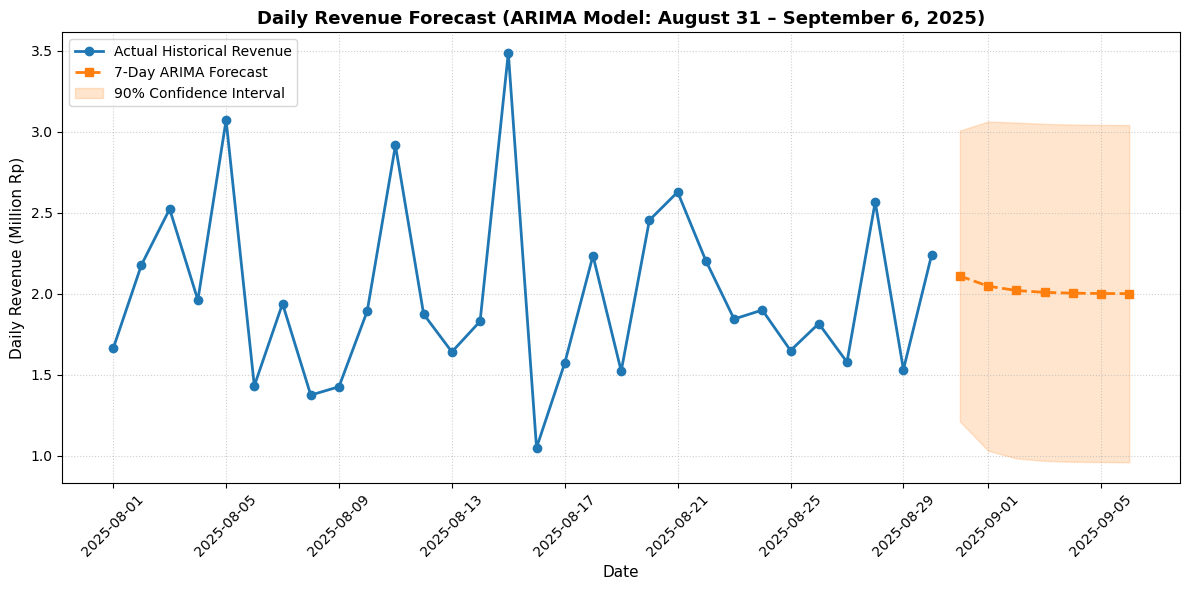

In [22]:
# Visualization of Time Series Forecast
plt.figure(figsize=(12, 6))

# Historical daily revenue
plt.plot(daily_df.index, daily_df['Revenue'] / 1e6, label='Actual Historical Revenue', marker='o', color='#1f77b4', linewidth=2)

# Forecast index
forecast_index = pd.date_range(start='2025-08-31', periods=7, freq='D')
forecast_values = forecast_7d_df['mean'].values / 1e6
lower_bound = forecast_7d_df['mean_ci_lower'].values / 1e6
upper_bound = forecast_7d_df['mean_ci_upper'].values / 1e6

plt.plot(forecast_index, forecast_values, label='7-Day ARIMA Forecast', marker='s', linestyle='--', color='#ff7f0e', linewidth=2)
plt.fill_between(forecast_index, lower_bound, upper_bound, color='#ff7f0e', alpha=0.2, label='90% Confidence Interval')

plt.title('Daily Revenue Forecast (ARIMA Model: August 31 – September 6, 2025)', fontsize=13, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Daily Revenue (Million Rp)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', frameon=True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('predictive_revenue_forecast.png', dpi=300)
plt.show()

In [1]:
import pandas as pd
import streamlit as st

data = {
    "Class / Metric": ["Class 0", "Class 1", "Macro Avg", "Weighted Avg"],
    "Precision": [0.57, 0.52, 0.54, 0.55],
    "Recall": [0.65, 0.43, 0.54, 0.55],
    "F1-Score": [0.61, 0.47, 0.54, 0.54],
    "Support": [43, 37, 80, 80],
}
df_report = pd.DataFrame(data)

st.dataframe(df_report, use_container_width=True)
st.metric("ROC-AUC Score", "0.5739", delta="-0.22 vs Target (0.80)")

2026-09-20 23:59:58.005 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 00:00:03.857 
  command:

    streamlit run /opt/anaconda3/lib/python3.13/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-09-21 00:00:03.947 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 00:00:04.187 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-21 00:00:04.234 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data for classification report visualization
metrics_data = [
    [0.57, 0.65, 0.61],  # Class 0
    [0.52, 0.43, 0.47],  # Class 1
    [0.54, 0.54, 0.54],  # Macro avg
    [0.55, 0.55, 0.54]   # Weighted avg
]
y_labels = ['Class 0 (Negative)', 'Class 1 (Positive)', 'Macro Average', 'Weighted Average']
x_labels = ['Precision', 'Recall', 'F1-Score']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [1.4, 1]})

# 1. Heatmap for Classification Report
sns.heatmap(metrics_data, annot=True, cmap='Blues', fmt='.2f', 
            xticklabels=x_labels, yticklabels=y_labels, cbar=True,
            vmin=0.3, vmax=0.8, ax=ax1, annot_kws={"size": 12, "weight": "bold"})
ax1.set_title('Classification Report Heatmap\n(Accuracy: 55.0% | Support: 80)', fontsize=12, fontweight='bold', pad=12)

# Annotate support values to the right of ax1
supports = [43, 37, 80, 80]
for i, s in enumerate(supports):
    ax1.text(3.4, i + 0.5, f"Support: {s}", verticalalignment='center', fontsize=10, color='#333333', style='italic')

# 2. Simulated ROC Curve matching AUC = 0.5739
fpr = [0.0, 0.15, 0.35, 0.55, 0.75, 1.0]
tpr = [0.0, 0.22, 0.45, 0.62, 0.81, 1.0]
# Calculate trapezoidal AUC check
from sklearn.metrics import auc
roc_auc_val = auc(fpr, tpr)

ax2.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'Model ROC (AUC = 0.5739)')
ax2.plot([0, 1], [0, 1], color='#d9534f', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.50)')
ax2.fill_between(fpr, tpr, alpha=0.15, color='#1f77b4')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=10)
ax2.set_ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=10)
ax2.set_title('ROC-AUC Performance Curve', fontsize=12, fontweight='bold', pad=12)
ax2.legend(loc="lower right", frameon=True)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('classification_metrics_visual.png', dpi=300)
plt.show()

/var/folders/n4/5f0j234x5m79703ndtqxkcr00000gn/T/ipykernel_12611/1505579393.py:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


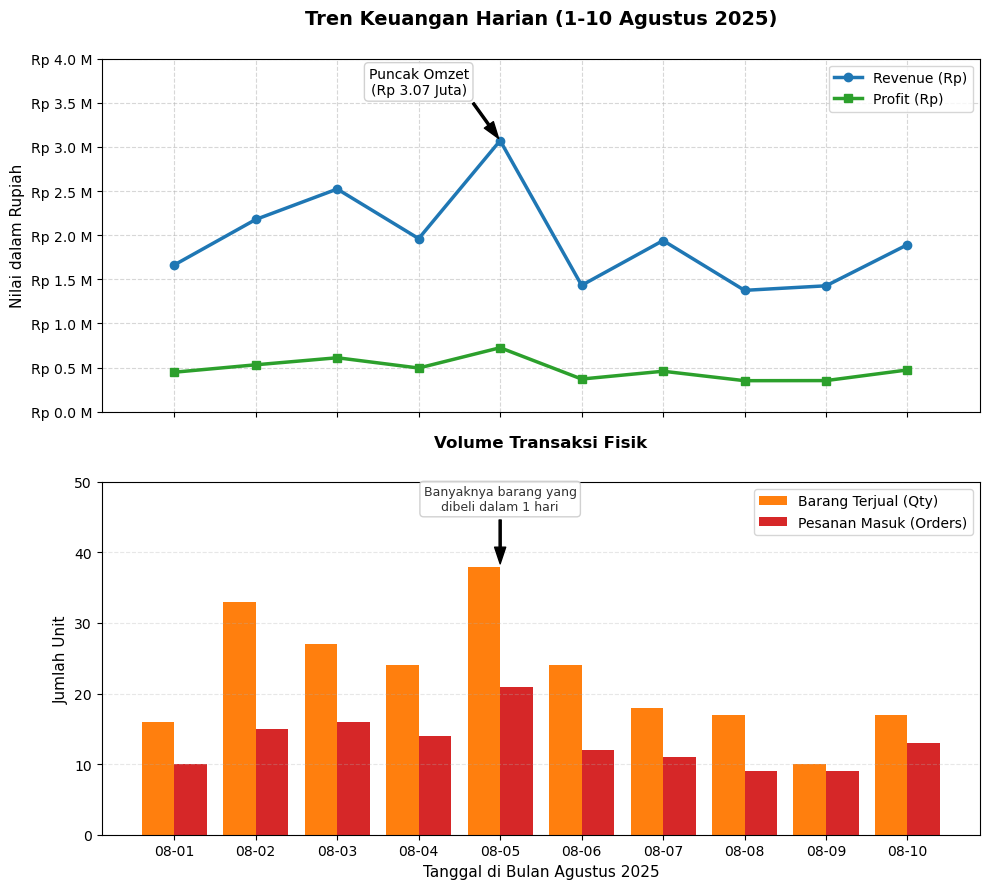

In [2]:

import matplotlib.pyplot as plt
import numpy as np

# Data dari 1 hingga 10 Agustus 2025
dates = ['08-01', '08-02', '08-03', '08-04', '08-05', '08-06', '08-07', '08-08', '08-09', '08-10']
revenue = [1662500, 2178000, 2523000, 1961000, 3072000, 1431500, 1939000, 1374500, 1426000, 1892500]
profit = [446500, 530600, 610500, 494000, 724300, 369100, 457700, 350600, 351600, 472400]
orders = [10, 15, 16, 14, 21, 12, 11, 9, 9, 13]
qty = [16, 33, 27, 24, 38, 24, 18, 17, 10, 17]

# Memperbesar ukuran figur agar lebih lega
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

# --- Grafik 1: Revenue vs Profit ---
ax1.plot(dates, revenue, marker='o', color='#1f77b4', linewidth=2.5, label='Revenue (Rp)')
ax1.plot(dates, profit, marker='s', color='#2ca02c', linewidth=2.5, label='Profit (Rp)')
ax1.set_title('Tren Keuangan Harian (1-10 Agustus 2025)', fontsize=14, fontweight='bold', pad=25)
ax1.set_ylabel('Nilai dalam Rupiah', fontsize=11)

# Memberikan ruang kosong ekstra di atas grafik (maksimal Rp 4 Juta) agar teks tidak menabrak judul
ax1.set_ylim(0, 4000000) 
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right')

# Anotasi Puncak Omzet dengan kotak latar agar rapi
ax1.annotate('Puncak Omzet\n(Rp 3.07 Juta)', 
             xy=(4, 3072000), # Indeks 4 = 08-05
             xytext=(3, 3600000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=10, ha='center',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#cccccc", alpha=0.9))

# Format angka Y-Axis ke jutaan
def millions(x, pos):
    return f'Rp {x*1e-6:.1f} M'
ax1.yaxis.set_major_formatter(plt.FuncFormatter(millions))

# --- Grafik 2: Orders vs Qty ---
x_pos = np.arange(len(dates))
ax2.bar(x_pos - 0.2, qty, width=0.4, color='#ff7f0e', label='Barang Terjual (Qty)')
ax2.bar(x_pos + 0.2, orders, width=0.4, color='#d62728', label='Pesanan Masuk (Orders)')
ax2.set_title('Volume Transaksi Fisik', fontsize=12, fontweight='bold', pad=25)
ax2.set_ylabel('Jumlah Unit', fontsize=11)
ax2.set_xlabel('Tanggal di Bulan Agustus 2025', fontsize=11)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(dates)

# Memberikan ruang kosong ekstra di atas grafik (maksimal 50 unit)
ax2.set_ylim(0, 50)
ax2.grid(True, linestyle='--', alpha=0.3, axis='y')
ax2.legend(loc='upper right')

# Anotasi Barang dengan kotak latar
ax2.annotate('Banyaknya barang yang\ndibeli dalam 1 hari', 
             xy=(4, 38), 
             xytext=(4, 46),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=9, ha='center', color='#333333',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#cccccc", alpha=0.9))

plt.tight_layout()
plt.show()